# Projet — Modèle ML Régression

**Objectif** : Prédire le prix par cup (`prix_cup`) d'un fruit ou légume.

**Approche** : On compare 5 modèles de régression et on sélectionne le meilleur.

**Fichier** : `fruits_legumes_enrichi.csv` — 710 lignes, 5 années

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

ROUGE = '#C0392B'
BLEU  = '#3498DB'
VERT  = '#2ECC71'

print('OK')

OK


## 1. Chargement et préparation des features

In [2]:
df = pd.read_csv('../DATA/CLEAN/fruits_legumes_enrichi.csv', sep=';', encoding='utf-8')

print(f'Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head(3)

Dataset : 710 lignes x 24 colonnes


,produit,forme,prix_detail,rendement,taille_cup,prix_cup,categorie,annee,forme_encoded,categorie_encoded,...,jours_gel,jours_chaleur,precip_totale,prix_diesel,prix_electricite,urea,dap,tsp,mop,prix_bls
0,Watermelon,Fresh,0.3334,0.520000,0.330693,0.2120,fruit,2013,0,1,...,6.0,1.0,511.2,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
1,Turnip greens,Frozen,1.4730,0.776027,0.352740,0.6696,legume,2013,2,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
2,Turnip greens,Fresh,2.4717,0.750000,0.319670,1.0535,legume,2013,0,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536


In [3]:
df

,produit,forme,prix_detail,rendement,taille_cup,prix_cup,categorie,annee,forme_encoded,categorie_encoded,...,jours_gel,jours_chaleur,precip_totale,prix_diesel,prix_electricite,urea,dap,tsp,mop,prix_bls
0,Watermelon,Fresh,0.333400,0.520000,0.330693,0.212000,fruit,2013,0,1,...,6.0,1.0,511.2,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
1,Turnip greens,Frozen,1.473000,0.776027,0.352740,0.669600,legume,2013,2,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
2,Turnip greens,Fresh,2.471700,0.750000,0.319670,1.053500,legume,2013,0,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
3,Turnip greens,Canned,0.965300,0.650000,0.352740,0.523800,legume,2013,1,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
4,Tomatoes,Canned,0.924800,1.000000,0.540133,0.499500,legume,2013,1,0,...,6.0,74.0,142.1,4.1267,14.3,304.0,474.0,390.0,355.0,1.848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705,Artichoke,Canned,3.505101,0.650000,0.385800,2.579113,legume,2023,1,0,...,6.0,56.0,1097.6,4.2421,14.3,358.0,550.0,480.0,383.0,1.536
706,Asparagus,Fresh,3.212453,0.493800,0.396800,2.581436,legume,2023,0,0,...,6.0,56.0,1097.6,4.2421,14.3,358.0,550.0,480.0,383.0,1.536
707,"Apricots, in syrup or water",Canned,2.556248,0.650000,0.440900,1.734019,fruit,2023,1,1,...,6.0,56.0,1097.6,4.2421,14.3,358.0,550.0,480.0,383.0,1.536
708,Asparagus,Frozen,6.780905,1.033500,0.396800,2.603590,legume,2023,2,0,...,6.0,56.0,1097.6,4.2421,14.3,358.0,550.0,480.0,383.0,1.536


In [4]:
import missingno as msno

<Axes: >

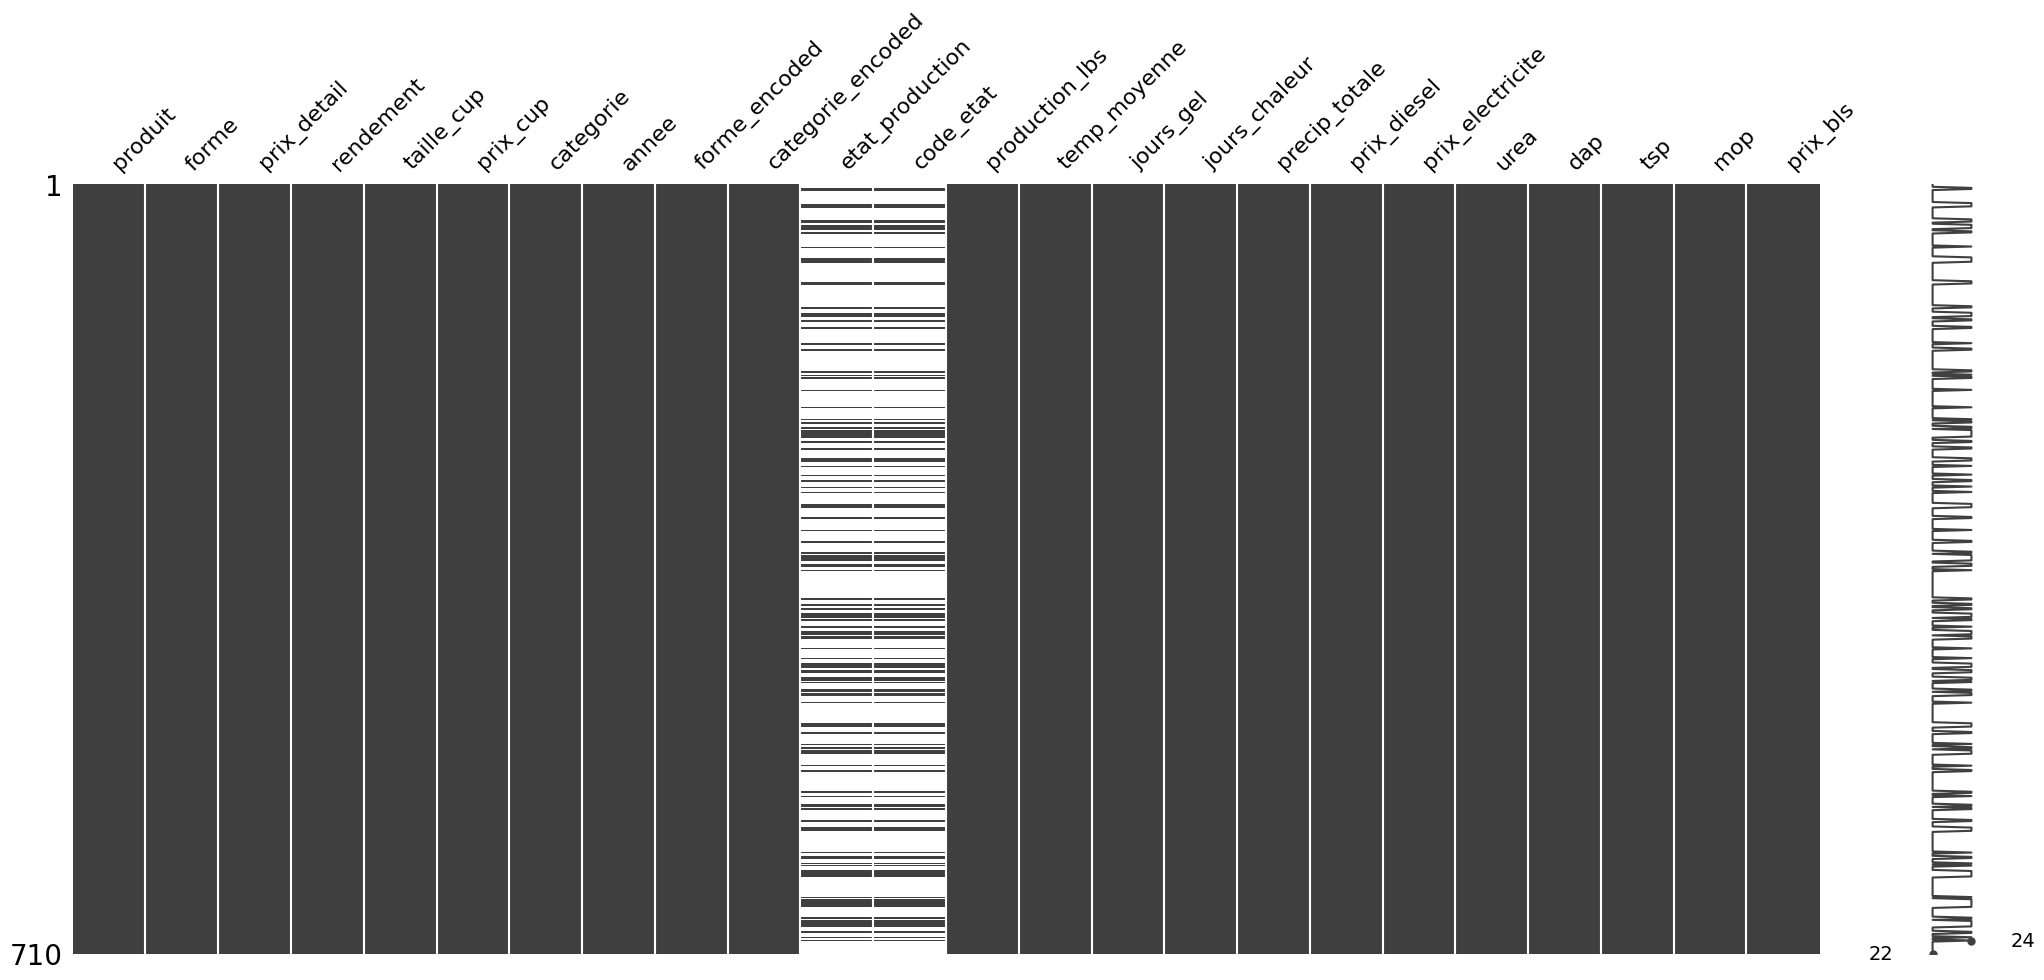

In [5]:
msno.matrix(df)

In [6]:
# Sélection des features pour le modèle
# On choisit les variables numériques pertinentes
# On exclut etat_production et code_etat (texte, non utilisables directement)
# On exclut dap, tsp, mop car très corrélés avec urea (multicolinéarité)
FEATURES = [
    'prix_detail',       # Prix en rayon — feature principale
    'rendement',         # Part utilisable après préparation
    'taille_cup',        # Taille de la portion
    'forme_encoded',     # Fresh=0, Canned=1, Frozen=2, Juice=3, Dried=4
    'categorie_encoded', # fruit=1, legume=0
    'annee',             # Capture l'inflation dans le temps
    'production_lbs',    # Volume de production de l'état producteur
    'temp_moyenne',      # Température annuelle de la zone de production
    'jours_gel',         # Risque climatique — jours sous 0°C
    'prix_diesel',       # Coût du transport
    'prix_electricite',  # Coût du stockage réfrigéré
    'urea',              # Prix des engrais — proxy des coûts de production
    #'prix_bls',          # Prix retail BLS — référence complémentaire
]

# Variable cible : prix réel d'une portion (valeur continue = régression)
CIBLE = 'prix_cup'

# On garde uniquement les colonnes présentes et on supprime les NaN restants
features_ok = [f for f in FEATURES if f in df.columns]
df_ml = df[features_ok + [CIBLE]].dropna().copy()

print(f'Features utilisées : {len(features_ok)}')
print(f'Dataset ML         : {df_ml.shape[0]} lignes')
print(f'Variable cible     : {CIBLE} — min={df_ml[CIBLE].min():.2f}$ max={df_ml[CIBLE].max():.2f}$')

Features utilisées : 12
Dataset ML         : 710 lignes
Variable cible     : prix_cup — min=0.17$ max=4.28$


## 2. Train / Test Split

In [7]:
X = df_ml[features_ok]
y = df_ml[CIBLE]

# Split 80% entraînement / 20% test
# random_state=42 garantit la reproductibilité des résultats
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]} lignes (80%)')
print(f'Test  : {X_test.shape[0]} lignes (20%)')

# Normalisation — obligatoire pour LinearRegression et Ridge
# Les arbres (Random Forest, XGBoost) n'en ont pas besoin
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train : 568 lignes (80%)
Test  : 142 lignes (20%)


## 3. Entraînement des 5 modèles

In [8]:
# Définition des modèles
# True = utiliser les données normalisées, False = données brutes
MODELES = {
    'Linear Regression' : (LinearRegression(),                           True),
    'Ridge'             : (Ridge(alpha=1.0),                             True),
    'Random Forest'     : (RandomForestRegressor(n_estimators=100,
                                                 random_state=42),       False),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=100,
                                                     random_state=42),   False),
    'XGBoost'           : (XGBRegressor(n_estimators=100,
                                        random_state=42,
                                        verbosity=0),                    False),
}

resultats = []

for nom, (modele, normalise) in MODELES.items():
    X_tr = X_train_sc if normalise else X_train
    X_te = X_test_sc  if normalise else X_test

    modele.fit(X_tr, y_train)
    y_pred = modele.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    resultats.append({'Modele': nom, 'RMSE': round(rmse, 4),
                      'MAE': round(mae, 4), 'R2': round(r2, 4)})
    print(f'{nom:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

df_resultats = pd.DataFrame(resultats).sort_values('RMSE').reset_index(drop=True)
print('\nClassement (RMSE plus bas = meilleur) :')
print(df_resultats.to_string(index=False))

Linear Regression      RMSE=0.3576  MAE=0.2427  R2=0.6007
Ridge                  RMSE=0.3577  MAE=0.2425  R2=0.6005
Random Forest          RMSE=0.1056  MAE=0.0537  R2=0.9652
Gradient Boosting      RMSE=0.0925  MAE=0.0473  R2=0.9733
XGBoost                RMSE=0.0886  MAE=0.0451  R2=0.9755

Classement (RMSE plus bas = meilleur) :
           Modele   RMSE    MAE     R2
          XGBoost 0.0886 0.0451 0.9755
Gradient Boosting 0.0925 0.0473 0.9733
    Random Forest 0.1056 0.0537 0.9652
Linear Regression 0.3576 0.2427 0.6007
            Ridge 0.3577 0.2425 0.6005


## 4. Benchmark visuel des modèles

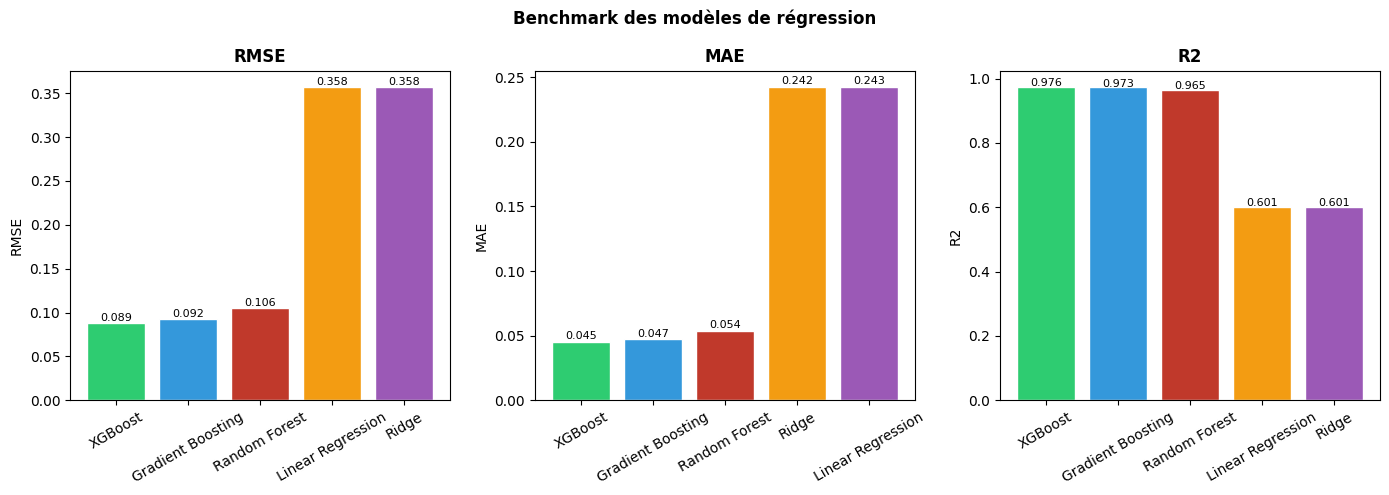

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
couleurs  = [VERT, BLEU, ROUGE, '#F39C12', '#9B59B6']

for i, metrique in enumerate(['RMSE', 'MAE', 'R2']):
    df_plot = df_resultats.sort_values(
        metrique, ascending=(metrique != 'R2'))
    axes[i].bar(df_plot['Modele'], df_plot[metrique],
                color=couleurs[:len(df_plot)], edgecolor='white')
    axes[i].set_title(f'{metrique}', fontweight='bold')
    axes[i].set_ylabel(metrique)
    axes[i].tick_params(axis='x', rotation=30)
    for j, val in enumerate(df_plot[metrique]):
        axes[i].text(j, val + 0.002, f'{val:.3f}',
                     ha='center', fontsize=8)

plt.suptitle('Benchmark des modèles de régression', fontweight='bold')
plt.tight_layout()
plt.show()

### Grid Search - Optimisation des hyperparamètres

In [10]:
# ── Grid Search — Optimisation des hyperparamètres XGBoost ──
# On cherche la meilleure combinaison de paramètres pour XGBoost
from sklearn.model_selection import GridSearchCV

# Grille des paramètres à tester
# On teste toutes les combinaisons possibles
param_grid = {
    'n_estimators'    : [100, 200, 300],      # Nombre d'arbres
    'max_depth'       : [3, 5, 7],            # Profondeur max de chaque arbre
    'learning_rate'   : [0.01, 0.05, 0.1],   # Vitesse d'apprentissage
    'subsample'       : [0.8, 1.0],           # % de lignes utilisées par arbre
    'colsample_bytree': [0.8, 1.0],           # % de colonnes utilisées par arbre
}

# GridSearchCV teste toutes les combinaisons avec cross-validation à 5 folds
grid_search = GridSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_grid = param_grid,
    cv         = 5,              # 5 folds de cross-validation
    scoring    = 'r2',           # On optimise le R²
    n_jobs     = -1,             # Utilise tous les coeurs du PC
    verbose    = 1               # Affiche la progression
)

print("Lancement du Grid Search...")
print(f"Nombre de combinaisons testées : {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree'])}")

grid_search.fit(X_train, y_train)

# Résultats
print(f"\nMeilleurs paramètres trouvés :")
for param, valeur in grid_search.best_params_.items():
    print(f"  {param} : {valeur}")

print(f"\nMeilleur R² cross-validation : {grid_search.best_score_:.4f}")

# Test sur les données de test
meilleur_modele = grid_search.best_estimator_
y_pred_gs = meilleur_modele.predict(X_test)
r2_gs   = r2_score(y_test, y_pred_gs)
rmse_gs = np.sqrt(mean_squared_error(y_test, y_pred_gs))

print(f"\nRésultats sur le jeu de test :")
print(f"  R²   = {r2_gs:.4f}")
print(f"  RMSE = {rmse_gs:.4f} $/cup")
print(f"\nComparaison avec le modèle de base :")
print(f"  R² baseline  = 0.9755 → R² optimisé = {r2_gs:.4f}")
print(f"  RMSE baseline = 0.0886 → RMSE optimisé = {rmse_gs:.4f}")

Lancement du Grid Search...
Nombre de combinaisons testées : 108
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs paramètres trouvés :
  colsample_bytree : 1.0
  learning_rate : 0.1
  max_depth : 3
  n_estimators : 300
  subsample : 0.8

Meilleur R² cross-validation : 0.9815

Résultats sur le jeu de test :
  R²   = 0.9782
  RMSE = 0.0835 $/cup

Comparaison avec le modèle de base :
  R² baseline  = 0.9755 → R² optimisé = 0.9782
  RMSE baseline = 0.0886 → RMSE optimisé = 0.0835


## 5. Cross-validation — vérification de l'overfitting

In [10]:
# La cross-validation découpe les données en 5 parties
# et entraîne le modèle 5 fois sur des sous-ensembles différents
# Si le R2 moyen est proche du R2 du test → pas d'overfitting
# Si le R2 chute beaucoup → le modèle a mémorisé les données d'entraînement

meilleur_nom    = df_resultats.iloc[0]['Modele']
meilleur_modele = MODELES[meilleur_nom][0]
normalise       = MODELES[meilleur_nom][1]
X_cv            = X_train_sc if normalise else X_train

scores = cross_val_score(meilleur_modele, X_cv, y_train,
                         cv=5, scoring='r2')

print(f'Cross-validation 5 folds — {meilleur_nom}')
print(f'  Scores  : {scores.round(3)}')
print(f'  Moyenne : {scores.mean():.3f}')
print(f'  Std     : {scores.std():.3f}')
print(f'  R2 test : {df_resultats.iloc[0]["R2"]}')
print()

diff = abs(scores.mean() - df_resultats.iloc[0]['R2'])
if diff < 0.05:
    print('Pas d overfitting — R2 cross-val proche du R2 test')
elif diff < 0.15:
    print('Léger overfitting — écart modéré entre cross-val et test')
else:
    print('Overfitting probable — écart important entre cross-val et test')

Cross-validation 5 folds — XGBoost
  Scores  : [0.949 0.965 0.947 0.968 0.952]
  Moyenne : 0.956
  Std     : 0.009
  R2 test : 0.9755

Pas d overfitting — R2 cross-val proche du R2 test


## 6. Prédictions vs Réalité

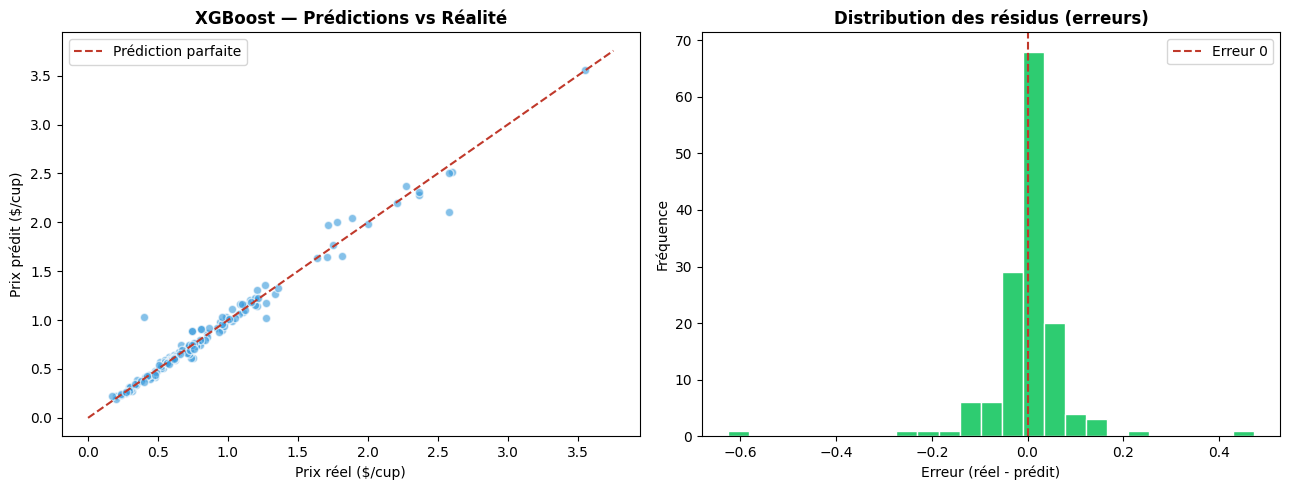

In [11]:
X_te       = X_test_sc if normalise else X_test
y_pred_best = meilleur_modele.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter prédictions vs valeurs réelles
# Si le modèle est parfait tous les points sont sur la ligne rouge
axes[0].scatter(y_test, y_pred_best, color=BLEU, alpha=0.6, edgecolors='white')
lim = max(y_test.max(), y_pred_best.max()) + 0.2
axes[0].plot([0, lim], [0, lim], color=ROUGE, linestyle='--',
             lw=1.5, label='Prédiction parfaite')
axes[0].set_title(f'{meilleur_nom} — Prédictions vs Réalité', fontweight='bold')
axes[0].set_xlabel('Prix réel ($/cup)')
axes[0].set_ylabel('Prix prédit ($/cup)')
axes[0].legend()

# Distribution des résidus (erreurs)
# Un bon modèle a des résidus centrés sur 0 et symétriques
residus = y_test.values - y_pred_best
axes[1].hist(residus, bins=25, color=VERT, edgecolor='white')
axes[1].axvline(0, color=ROUGE, linestyle='--', lw=1.5, label='Erreur 0')
axes[1].set_title('Distribution des résidus (erreurs)', fontweight='bold')
axes[1].set_xlabel('Erreur (réel - prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Importance des features

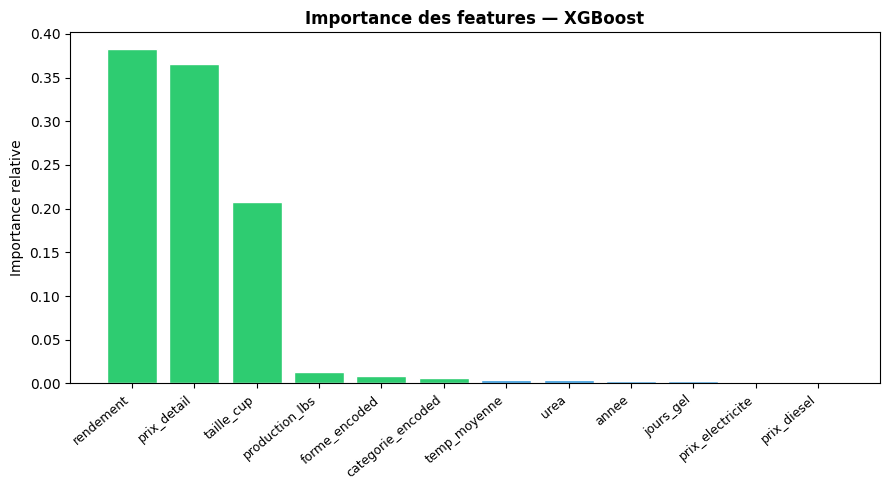

Top 5 features les plus importantes :
rendement         0.383
prix_detail       0.366
taille_cup        0.208
production_lbs    0.013
forme_encoded     0.009
dtype: float32


In [12]:
if hasattr(meilleur_modele, 'feature_importances_'):
    importances = pd.Series(
        meilleur_modele.feature_importances_,
        index=features_ok
    ).sort_values(ascending=False)

    couleurs_imp = [VERT if v >= importances.median() else BLEU
                    for v in importances.values]

    plt.figure(figsize=(9, 5))
    plt.bar(importances.index, importances.values,
            color=couleurs_imp, edgecolor='white')
    plt.title(f'Importance des features — {meilleur_nom}', fontweight='bold')
    plt.ylabel('Importance relative')
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Top 5 features les plus importantes :')
    print(importances.head(5).round(3))

else:
    # Pour LinearRegression et Ridge — on affiche les coefficients
    coefs = pd.Series(
        np.abs(meilleur_modele.coef_), index=features_ok
    ).sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    plt.bar(coefs.index, coefs.values, color=BLEU, edgecolor='white')
    plt.title(f'Coefficients — {meilleur_nom}', fontweight='bold')
    plt.ylabel('Valeur absolue du coefficient')
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Top 5 coefficients :')
    print(coefs.head(5).round(3))

## 8. Bilan

In [13]:
print('=' * 55)
print('BILAN ML — RÉGRESSION')
print('=' * 55)
print(f'Variable cible  : prix_cup ($/cup)')
print(f'Features        : {len(features_ok)}')
print(f'Train           : {X_train.shape[0]} lignes')
print(f'Test            : {X_test.shape[0]} lignes')
print()
print('Benchmark :')
print(df_resultats.to_string(index=False))
print()
print(f'Meilleur modèle : {meilleur_nom}')
print(f'  RMSE = {df_resultats.iloc[0]["RMSE"]} $/cup')
print(f'  MAE  = {df_resultats.iloc[0]["MAE"]} $/cup')
print(f'  R2   = {df_resultats.iloc[0]["R2"]}')
print()

r2_val = df_resultats.iloc[0]['R2']
if r2_val >= 0.8:
    print('Interprétation R2 : Excellent — le modèle explique bien la variance du prix')
elif r2_val >= 0.6:
    print('Interprétation R2 : Bon — le modèle capture les tendances principales')
else:
    print('Interprétation R2 : Moyen — des features supplémentaires amélioreraient les résultats')
print('=' * 55)

BILAN ML — RÉGRESSION
Variable cible  : prix_cup ($/cup)
Features        : 12
Train           : 568 lignes
Test            : 142 lignes

Benchmark :
           Modele   RMSE    MAE     R2
          XGBoost 0.0886 0.0451 0.9755
Gradient Boosting 0.0925 0.0473 0.9733
    Random Forest 0.1056 0.0537 0.9652
Linear Regression 0.3576 0.2427 0.6007
            Ridge 0.3577 0.2425 0.6005

Meilleur modèle : XGBoost
  RMSE = 0.0886 $/cup
  MAE  = 0.0451 $/cup
  R2   = 0.9755

Interprétation R2 : Excellent — le modèle explique bien la variance du prix
